In [1]:
import pathlib
import sys
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from seagliderOG1 import convertOG1, writers
from tqdm import tqdm
import xarray as xr
import importlib
import numpy as np

script_dir = pathlib.Path().parent.absolute()
parent_dir = script_dir.parents[0]
sys.path.append(str(parent_dir))
from dissipationSML import reading, plotting, tools,interactive

In [2]:
importlib.reload(reading)
importlib.reload(plotting)
importlib.reload(tools)
importlib.reload(interactive)

<module 'dissipationSML.interactive' from '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/interactive.py'>

## 1. Chose the glider and the mission

In [ ]:
# Example usage
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
selected_glider = interactive.interactive_glider_selection(yaml_path)

Dropdown(description='Select Glider:', index=6, options=('005', '012', '014', '016', '101', '102', '103', '104…

Dropdown(description='Select Mission:', index=1, options=('02/07 (dives: 679)', '11/07 (dives: 524)', '02/09 (…

Button(description='Confirm Selection', style=ButtonStyle())

Selected Path: https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/103/20071113/


In [27]:
### From the chosen glider mission, the important variables are taken. The destination folder is also selected here.
### The mission path gives the exact path to the dedicated mission of the chosen glider. It will be used later to save and load the concatenated/converted data
data_path = selected_glider['path']
end_profile = selected_glider['dives']
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"
mission_path = destination_folder + '/' + selected_glider['glider'] + '/' + selected_glider['mission']

### 1.1 Load the data into a list of .nc files and then convert into OG1 format which is also concatenating the data. 
### The data is saved at the mission path 

In [28]:
### All datasets from the glider mission are downloaded and then loaded as .nc file into one list
datasets = reading.read_basestation(data_path, destination_path=destination_folder, start_profile=1, end_profile=end_profile)


File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20071113/p1030001_20071113.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20071113/p1030002_20071113.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20071113/p1030003_20071113.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20071113/p1030004_20071113.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20071113/p1030005_20071114.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20071113/p1030006_20071114.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20071113/p1030007_20071114.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20071113/p1030008_20071114.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20071113/p1030009_20071114.nc
File already exists: /Users/tillmorit

In [29]:
variables_needed = ['LONGITUDE','LATITUDE','TIME','DEPTH','GLIDER_VERT_VELO_MODEL','THETA','TEMP',
                    'GLIDE_SPEED','SIGTHETA','SIGMA_T','PSAL','PRES','GLIDER_HORZ_VELO_MODEL','DIVE_NUMBER','PROFILE_NUMBER','PSAL_RAW','TEMP_RAW']
### convert the dataset to OG1 format only with the variables needed
ds = reading.convert_with_variables(datasets,variables_needed)
### calculate potential density from raw data and add it to the dataset
ds = tools.add_pot_densities(ds,use_raw=True)
ds = tools.add_pot_densities(ds,use_raw=False)

Converting datasets to OG1 format:  76%|███████▌  | 396/524 [03:09<01:01,  2.09it/s]
/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/seagliderOG1/tools.py:472: SyntaxWarning: invalid escape sequence '\d'
  fill_val = 2 ** (int(re.findall("\d+", str(new_dtype))[0]) - 1) - 1


ValueError: invalid literal for int() with base 10: b'@'

In [ ]:
### save the OG1 dataset at the destination folder
writers.save_dataset(ds, mission_path + '/all_data_OG1.nc')

True

### 2. Load the dataset and do some plotting

In [ ]:
ds = xr.open_dataset(mission_path + '/all_data_OG1.nc')

In [ ]:
ds

<xarray.Dataset> Size: 17MB
Dimensions:                 (N_MEASUREMENTS: 144321)
Coordinates:
    LONGITUDE               (N_MEASUREMENTS) float64 1MB ...
    LATITUDE                (N_MEASUREMENTS) float64 1MB ...
    TIME                    (N_MEASUREMENTS) datetime64[ns] 1MB ...
    DEPTH                   (N_MEASUREMENTS) float64 1MB ...
Dimensions without coordinates: N_MEASUREMENTS
Data variables: (12/17)
    GLIDER_VERT_VELO_MODEL  (N_MEASUREMENTS) float32 577kB ...
    THETA                   (N_MEASUREMENTS) float32 577kB ...
    TEMP                    (N_MEASUREMENTS) float32 577kB ...
    GLIDE_SPEED             (N_MEASUREMENTS) float32 577kB ...
    SIGTHETA                (N_MEASUREMENTS) float32 577kB ...
    SIGMA_T                 (N_MEASUREMENTS) float32 577kB ...
    ...                      ...
    PSAL_RAW                (N_MEASUREMENTS) float32 577kB ...
    TEMP_RAW                (N_MEASUREMENTS) float32 577kB ...
    SIGTHETA_RAW            (N_MEASUREMENTS) float64 1MB ...
    SIGMA_T_RAW             (N_MEASUREMENTS) float64 1MB ...
    SIGMA_1_RAW             (N_MEASUREMENTS) float64 1MB ...
    SIGMA_1                 (N_MEASUREMENTS) float64 1MB ...
Attributes: (12/39)
    title:                                      OceanGliders trajectory file
    id:                                         sg102_20061112T113646_delayed
    platform:                                   sub-surface gliders
    platform_vocabulary:                        https://vocab.nerc.ac.uk/coll...
    naming_authority:                           edu.washington.apl
    institution:                                School of Oceanography\nUnive...
    ...                                         ...
    keywords_vocabulary:                        NASA/GCMD Earth Science Keywo...
    license:                                    These data may be redistribut...
    acknowledgment:                             National Science Foundation, ...
    disclaimer:                                 Data provided AS-IS.
    file_version:                               2.71
    keywords:                                   Water Temperature, Conductivi...

### 2.1 Plot the glider track and minimum/mximum depth

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()])


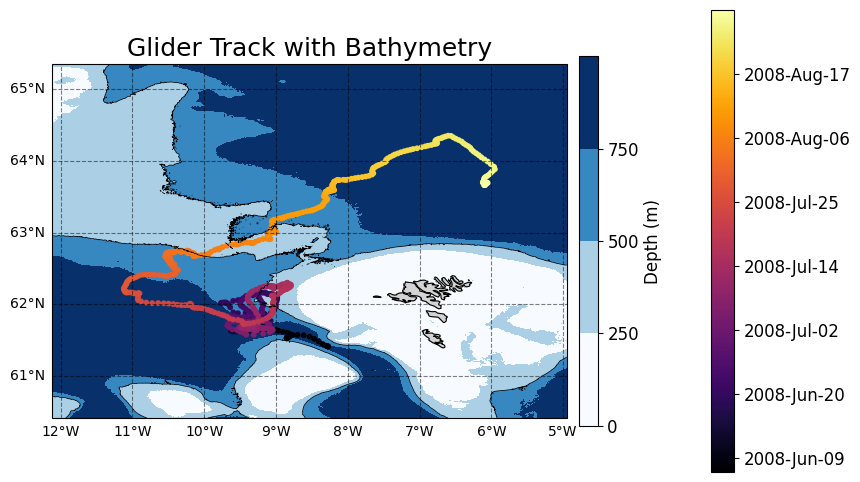

In [253]:
importlib.reload(plotting)
fig, ax = plotting.plot_glider_track(ds)
display(fig)
### save the figure
#fig.savefig(mission_path + '/glider_track.png', dpi=300)
del fig, ax

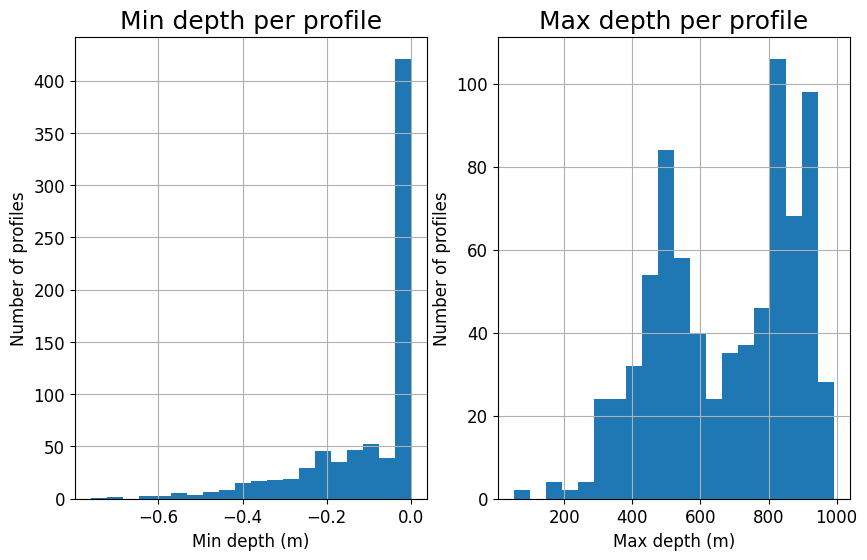

In [254]:
fig, ax = plotting.plot_min_max_depth(ds)
display(fig)
#fig.savefig(mission_path + '/min_max_histogram.png', dpi=300)
del fig, ax


### 2.2 Plot profiles interactively with the possibility of binning

In [255]:
profile_slider = widgets.SelectionSlider(options=np.unique(ds.PROFILE_NUMBER.values).astype(int), description='Profile number:', continuous_update=False)
raw_button = widgets.Checkbox(value=False, description='Raw data')
binning_slider = widgets.IntSlider(value=2, min=1, max=20, description='Binning (m):')
agg_button = widgets.ToggleButtons(options=['mean', 'median'],description='Aggregation:',disabled=False,button_style='')
#var_dropdown = widgets.Dropdown(options=var_options, value=var_options[0], description="Variable:")

In [256]:
interactive.interactive_profile(ds,profile_slider)

Output()

In [11]:
interactive.interactive_resolution_hist(ds, profile_slider)

interactive(children=(SelectionSlider(continuous_update=False, description='Profile number:', index=770, optio…

In [303]:
importlib.reload(tools)
mld_CR = tools.compute_mld(ds,variable='SIGMA_1',method='CR',threshold= -3,use_bins=False,binning=5)
mld_treshold = tools.compute_mld(ds,variable='SIGMA_T',method='threshold',threshold = 0.03,ref_depth=10,use_bins=False,binning=5)

No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below refere

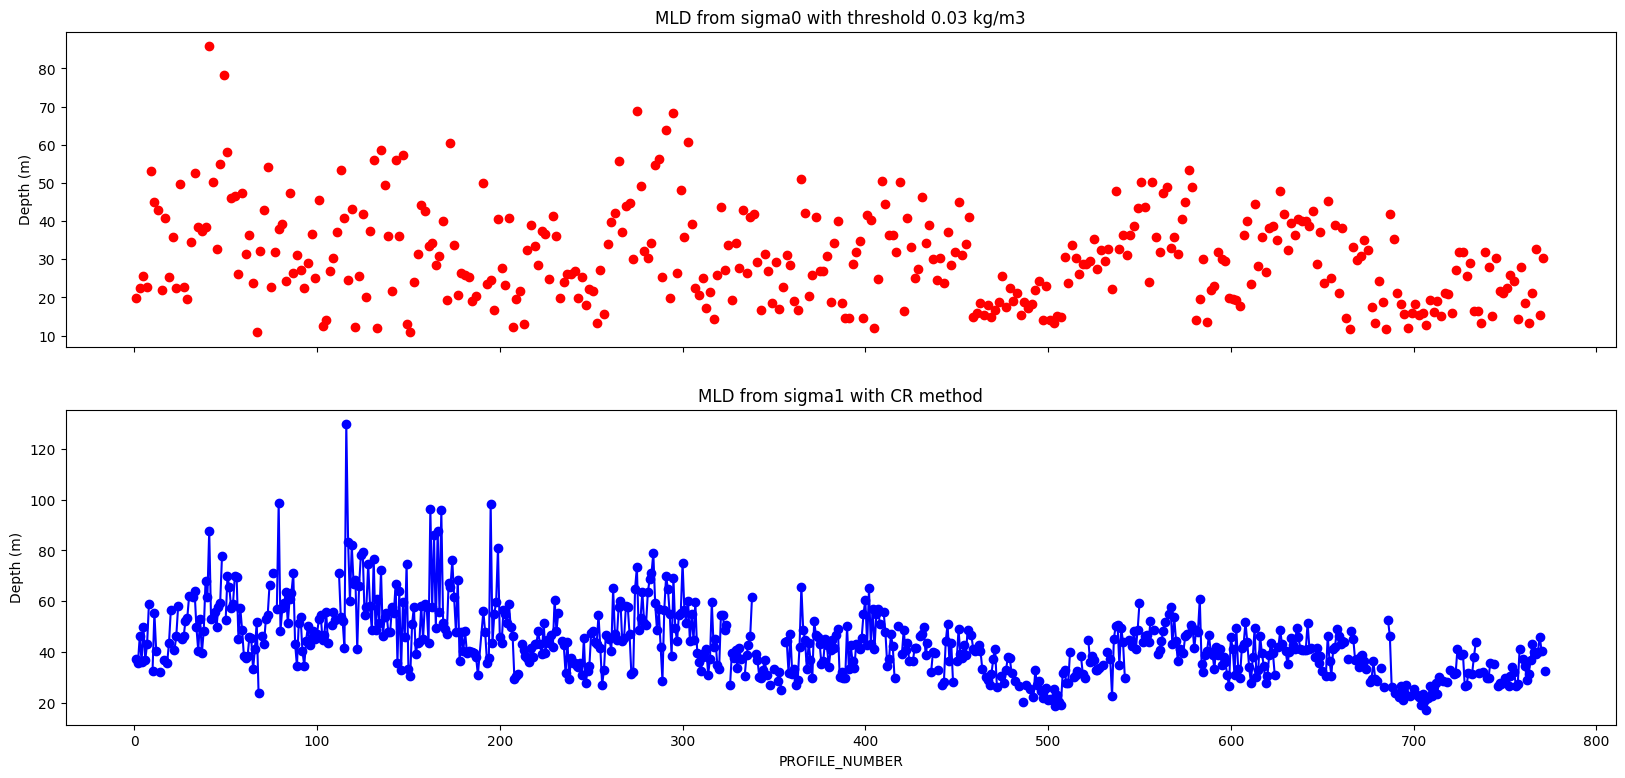

In [264]:
### plot three MLD profiles
fig, ax = plt.subplots(2, 1, figsize=(20, 9), sharex=True)
mld_treshold.plot(ax=ax[0], marker='o', color='red', label='MLD from SIGTHETA with threshold 0.03 kg/m3') 
mld_CR.plot(ax=ax[1], marker='o', color='blue', label='MLD from SIGMA1 with CR method')
ax[0].set_title('MLD from sigma0 with threshold 0.03 kg/m3')
ax[1].set_title('MLD from sigma1 with CR method')
ax[0].set_ylabel('Depth (m)')
ax[1].set_ylabel('Depth (m)')

plt.show()

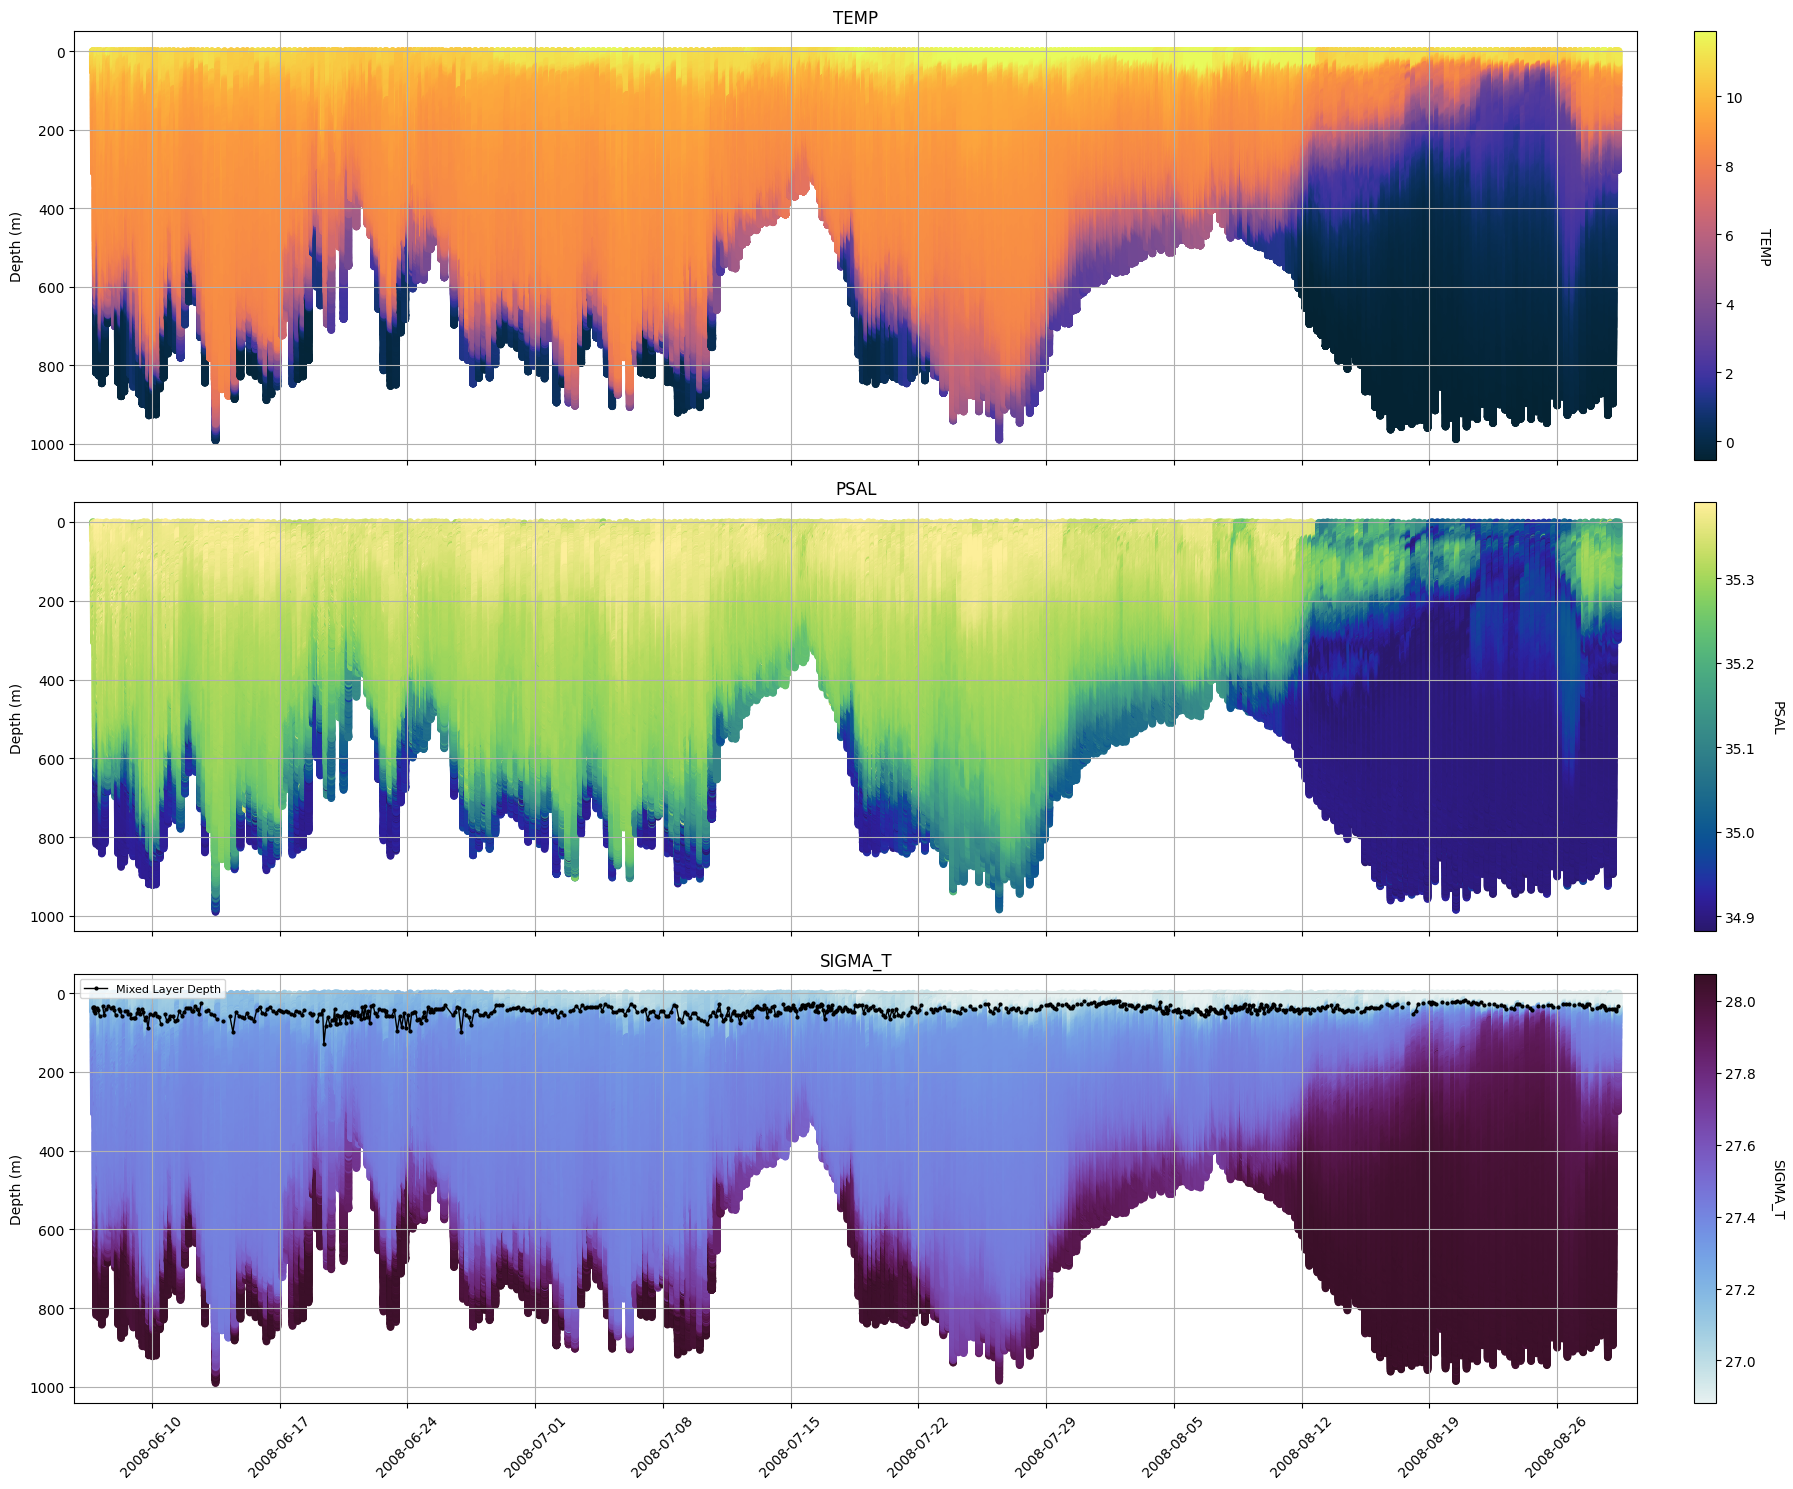

(<Figure size 2000x1500 with 6 Axes>,
 array([<Axes: title={'center': 'TEMP'}, ylabel='Depth (m)'>,
        <Axes: title={'center': 'PSAL'}, ylabel='Depth (m)'>,
        <Axes: title={'center': 'SIGMA_T'}, ylabel='Depth (m)'>],
       dtype=object))

In [306]:
importlib.reload(plotting)
plotting.plot_section(ds, ['TEMP','PSAL','SIGMA_T'], add_MLD=mld_CR)#,start_date='2008-07-01' ,end_date='2008-07-31')

In [5]:
### load the yaml file with yaml_path defined before
import yaml
# Load YAML from a file
with open(yaml_path, 'r') as file:
    config = yaml.safe_load(file)

In [6]:
config['gliders'][0]['missions'][0]['path'] = mission_path

In [7]:
config['gliders']

[{'name': '005',
  'missions': [{'date': '06/08',
    'dives': 386,
    'folder': '005/20080606',
    'path': '/Users/tillmoritz/Desktop/Master_thesis/Data/Glider/012/20070831'},
   {'date': '08/09', 'dives': 464, 'folder': '005/20090829'},
   {'date': '11/08', 'dives': 486, 'folder': '005/20081106'}]},
 {'name': '012',
  'missions': [{'date': '09/07', 'dives': 188, 'folder': '012/20070831'}]},
 {'name': '014',
  'missions': [{'date': '02/08', 'dives': 70, 'folder': '014/20080214'},
   {'date': '08/08', 'dives': 439, 'folder': '014/20080222'}]},
 {'name': '016',
  'missions': [{'date': '11/06', 'dives': 124, 'folder': '016/20061112'},
   {'date': '11/07', 'dives': 452, 'folder': '016/20071113'},
   {'date': '06/08', 'dives': 421, 'folder': '016/20080607'},
   {'date': '06/09', 'dives': 297, 'folder': '016/20090605'}]},
 {'name': '101',
  'missions': [{'date': '11/06', 'dives': 578, 'folder': '101/20061112'},
   {'date': '06/07', 'dives': 453, 'folder': '101/20070609'},
   {'date': '11/

In [26]:
mld_list = []
for glider in tqdm(config['gliders']):
    #print(glider['name'])
    for mission in glider['missions']:
        if mission['folder'] == 'no folder':
            #print('no folder')
            continue
        #print(destination_folder + mission['folder'])
        ds = xr.open_dataset(destination_folder + '/'+ mission['folder'] + '/all_data_OG1.nc')
        mld = tools.compute_mld(ds,variable='SIGMA_T',method='threshold',threshold = 0.03,ref_depth=10,use_bins=False,binning=5)
        mld_list.append(mld)

  0%|          | 0/9 [00:00<?, ?it/s]

No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below refere

 11%|█         | 1/9 [00:00<00:07,  1.02it/s]

No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below refere

 33%|███▎      | 3/9 [00:01<00:02,  2.73it/s]

...

 67%|██████▋   | 6/9 [00:03<00:01,  2.03it/s]

No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below refere

 67%|██████▋   | 6/9 [00:03<00:01,  1.84it/s]

No density values below reference depth 10 m exceed the threshold.
No data below reference depth 10 m
No data below reference depth 10 m
No density values below reference depth 10 m exceed the threshold.
No data below reference depth 10 m
No density values below reference depth 10 m exceed the threshold.
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth 10 m
No data below reference depth

FileNotFoundError: [Errno 2] No such file or directory: '/Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20071113/all_data_OG1.nc'

### 2.3 Plot the MLD, depending on the settings that were chosen and add it in the next step to the dataset

In [13]:
# Create sliders for longitude and latitude
default_coords = [[-14.0, 63.5], # First corner
                  [-13, 64.5], # Second corner
                  [-7.5, 62], # Third corner
                  [-9, 61]] # Fourth corner
# Create the interactive selector
get_region = plotting.interactive_region_selector(default_coords)

Button(description='Confirm Selection', style=ButtonStyle())

Output()

Region confirmed!


In [14]:
### get the coordinates of the region and create a new dataset with values only from this region
region = get_region()
ds_region = tools.cut_region(ds, region)

In [15]:
importlib.reload(interactive)
bad_profiles = interactive.interactive_bad_profile_checking(ds_region)

In [48]:
### cutting out profile numbers that are not needed
bad_profiles = np.array(bad_profiles)
ds = ds_region.isel(N_MEASUREMENTS=~np.isin(ds_region.PROFILE_NUMBER.values, bad_profiles))

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()])


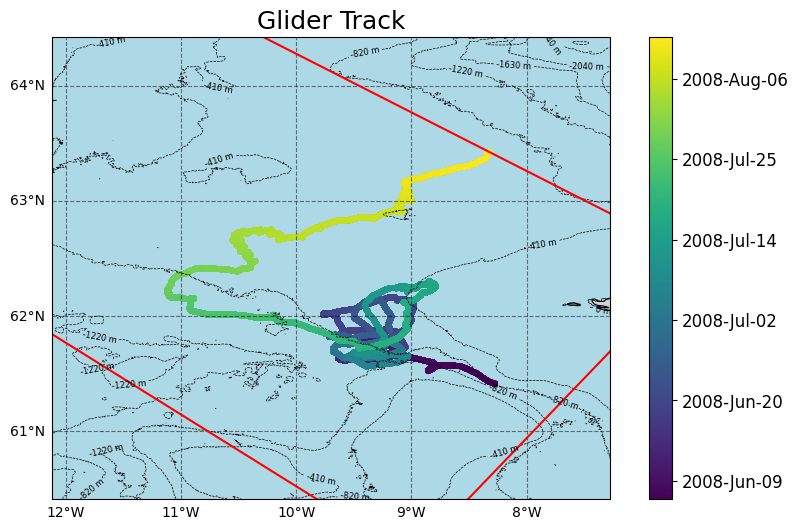

In [20]:
importlib.reload(plotting)
fig, ax = plotting.plot_glider_track(ds_region)
region.plot(ax=ax, add_label=False, line_kws={'color': 'red'})
display(fig)
#fig.savefig(mission_path + '/glider_track_region.png', dpi=300)
del fig, ax

In [ ]:
### save the dataset with MLD
#writers.save_dataset(ds, mission_path + '/all_data_OG1_with_MLD.nc')